In [246]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [247]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "high_grade_glioma"
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

# Vireo

In [253]:
vireo_matrix = pd.read_csv(DATA_PATH + f"vireo/{dataset}/similarity_matrix.csv", index_col=0)

In [ ]:
vireo_matrix.columns = [col.replace(".bam", "") for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([idx.replace(".bam", "") for idx in vireo_matrix.index])

In [ ]:
# Order rows and columns
ordered_samples = sorted(vireo_matrix.columns)
matrix_df = vireo_matrix.loc[ordered_samples, ordered_samples]

In [ ]:
vireo_matrix

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,0.000000,0.103802,0.122601,0.141360,0.111500,0.108087,0.124989,0.100283,0.112283,0.103813,...,0.140967,0.118805,0.121881,0.131588,0.124493,0.119837,0.182358,0.194635,0.184343,0.165485
GSM7305243_bulk,0.103802,0.000000,0.112568,0.125302,0.118563,0.118998,0.126267,0.111004,0.118045,0.111620,...,0.143154,0.121950,0.125186,0.134097,0.127490,0.123103,0.183858,0.196478,0.185268,0.168089
GSM7305244_bulk,0.122601,0.112568,0.000000,0.132856,0.133518,0.135522,0.132946,0.124689,0.131744,0.122002,...,0.168447,0.149336,0.152057,0.160137,0.154137,0.150056,0.209667,0.220342,0.210584,0.194431
GSM7305245_bulk,0.141360,0.125302,0.132856,0.000000,0.148875,0.152129,0.143888,0.143137,0.146256,0.144531,...,0.187233,0.168978,0.172004,0.179364,0.173622,0.170002,0.226911,0.238442,0.226486,0.213443
GSM7305246_bulk,0.111500,0.118563,0.133518,0.148875,0.000000,0.119325,0.136653,0.115296,0.124025,0.118183,...,0.158512,0.139221,0.142478,0.150123,0.144516,0.140483,0.198939,0.209471,0.199702,0.183502
GSM7305247_bulk,0.108087,0.118998,0.135522,0.152129,0.119325,0.000000,0.139549,0.112527,0.125422,0.118260,...,0.159401,0.139304,0.142871,0.150910,0.145183,0.140796,0.198885,0.209343,0.199519,0.183476
GSM7305248_bulk,0.124989,0.126267,0.132946,0.143888,0.136653,0.139549,0.000000,0.128747,0.132414,0.129719,...,0.177837,0.159152,0.162243,0.169840,0.164129,0.160250,0.218666,0.229925,0.218755,0.204135
GSM7305249_bulk,0.100283,0.111004,0.124689,0.143137,0.115296,0.112527,0.128747,0.000000,0.116789,0.108324,...,0.151552,0.131281,0.134325,0.142720,0.136678,0.132218,0.192877,0.203428,0.194258,0.176733
GSM7305250_bulk,0.112283,0.118045,0.131744,0.146256,0.124025,0.125422,0.132414,0.116789,0.000000,0.117943,...,0.167880,0.148457,0.151949,0.159484,0.154031,0.149927,0.208031,0.219692,0.208355,0.193469
GSM7305251_bulk,0.103813,0.111620,0.122002,0.144531,0.118183,0.118260,0.129719,0.108324,0.117943,0.000000,...,0.151322,0.132489,0.135544,0.143747,0.137917,0.133377,0.193690,0.204982,0.195338,0.177904


In [ ]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize ALL samples against ALL samples
    fig, ax = plt.subplots(figsize=(12, 12))
    cax = ax.matshow(matrix_df, cmap="Blues")

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left")
    ax.set_yticklabels(matrix_df.index)
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} similarity matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_all_samples_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_all_samples_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [284]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize bulk against single-cell samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "single-cell" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "bulk" in idx]
    ]

    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.matshow(sub_matrix, cmap="Oranges")

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_bulk_vs_singlecell_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_bulk_vs_singlecell_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

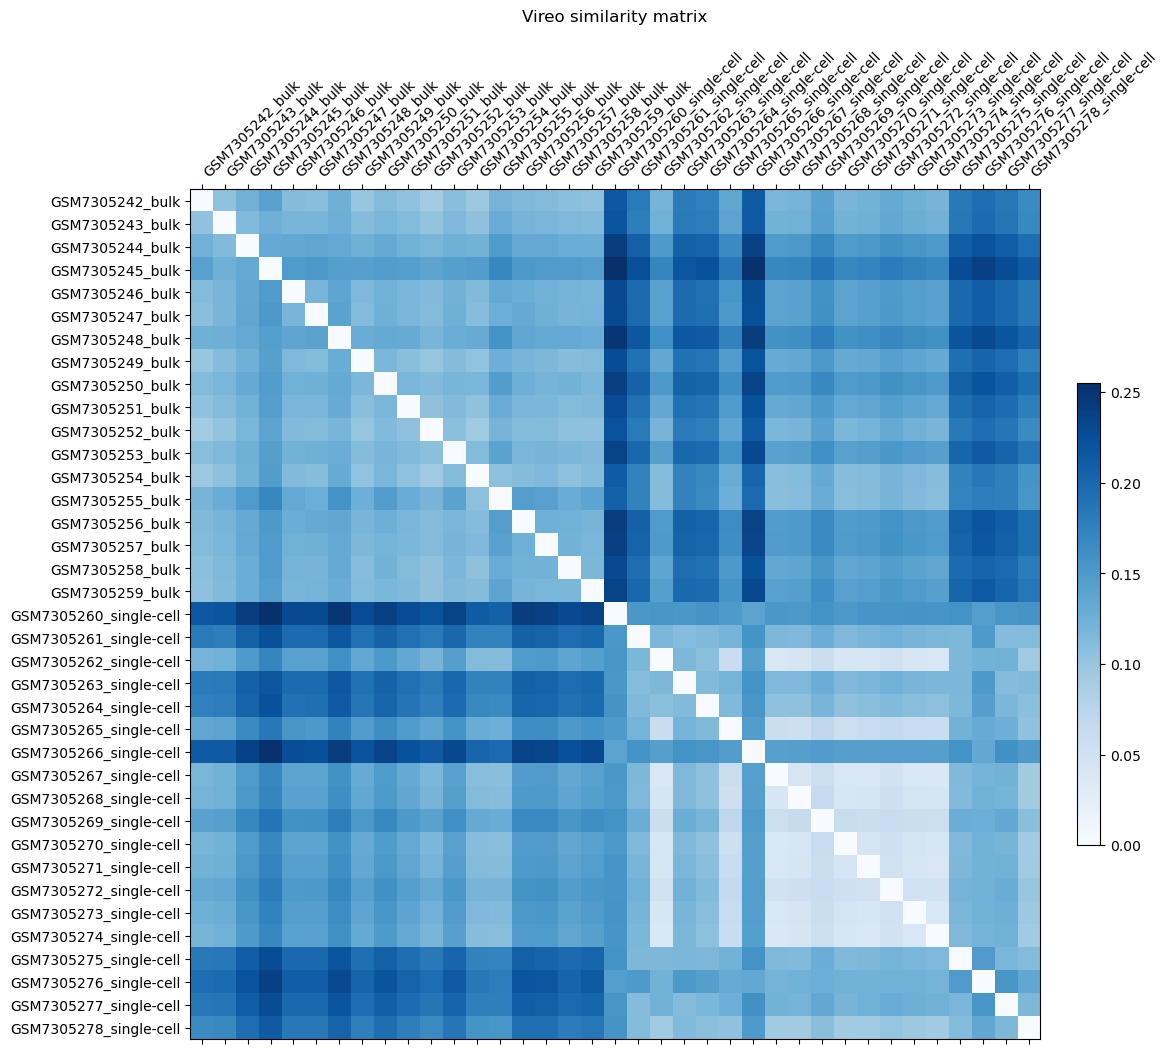

In [283]:
all_samples_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=False)

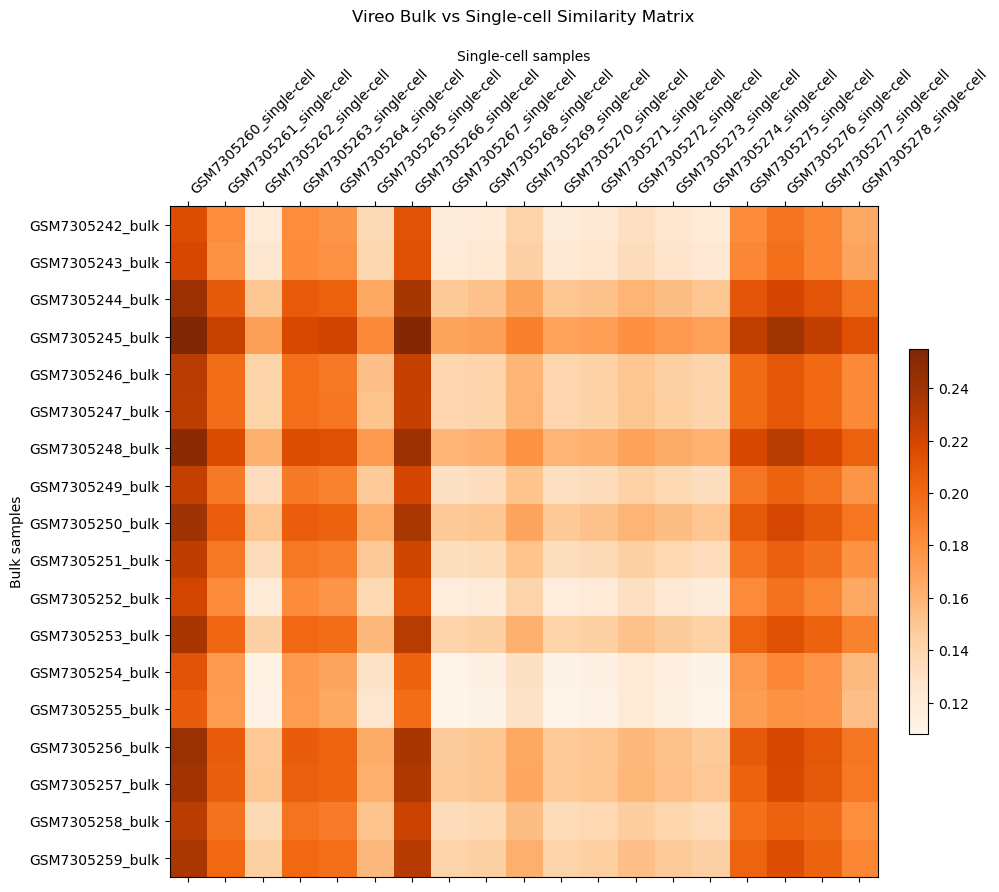

In [285]:
bulk_vs_singlecell_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=False)

# NGSCheckmate

In [291]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [292]:
ngscheckmate_dict = {
    x: 
    x.replace("_filtered_variants.vcf", "").replace("_bulk_chunk_ribo.bam", "")
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [293]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
GSM7305242_bulk,matched,GSM7305243_bulk,1.0,235.32
GSM7305242_bulk,matched,GSM7305244_bulk,1.0,243.18
GSM7305242_bulk,matched,GSM7305245_bulk,1.0,241.08
GSM7305242_bulk,matched,GSM7305246_bulk,1.0,252.25
GSM7305242_bulk,matched,GSM7305247_bulk,1.0,246.77


In [294]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [295]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [296]:
ngscheckmate_matrix

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,2.3532,2.4318,2.4108,2.5225,2.4677,2.5225,2.5225,2.5225,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305243_bulk,2.3532,NaN,2.3532,2.3532,2.3532,2.3532,2.3532,2.3532,2.3532,2.3532,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305244_bulk,2.4318,2.3532,NaN,2.4108,2.4318,2.4318,2.4318,2.4318,2.4318,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305245_bulk,2.4108,2.3532,2.4108,NaN,2.4108,2.4108,2.4108,2.4108,2.4108,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305246_bulk,2.5225,2.3532,2.4318,2.4108,NaN,2.4677,2.5276,2.5276,2.5276,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305247_bulk,2.4677,2.3532,2.4318,2.4108,2.4677,NaN,2.4677,2.4677,2.4677,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305248_bulk,2.5225,2.3532,2.4318,2.4108,2.5276,2.4677,NaN,2.5593,2.5358,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305249_bulk,2.5225,2.3532,2.4318,2.4108,2.5276,2.4677,2.5593,NaN,2.5358,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305250_bulk,2.5225,2.3532,2.4318,2.4108,2.5276,2.4677,2.5358,2.5358,NaN,2.3831,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421
GSM7305251_bulk,2.3831,2.3532,2.3831,2.3831,2.3831,2.3831,2.3831,2.3831,2.3831,NaN,...,0.5247,0.6214,0.3868,0.5687,0.4386,0.4363,0.8061,0.6338,1.2371,0.6421


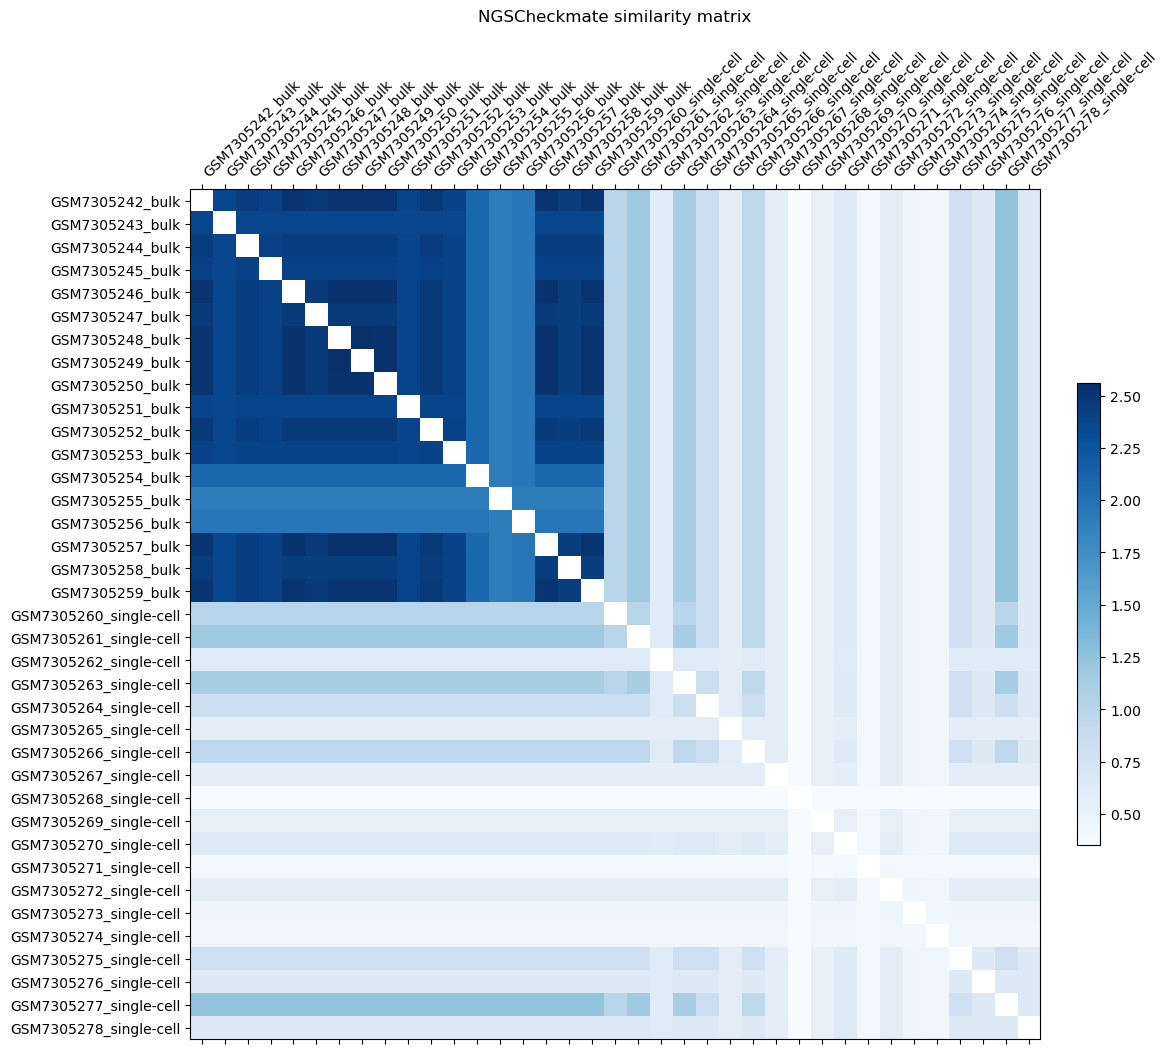

In [297]:
all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=False)

# HYSYS

In [201]:
hysys_df = pd.read_csv(DATA_PATH + f"hysys/{dataset}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [202]:
hysys_dict = {
    x: 
    x.replace("_bulk_chunk_ribo_filtered_variants.snps", "").replace("hgsoc/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [203]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
2251_bulk_chunk_ribo,2251_bulk_chunk_ribo,1.000,476338
2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,0.201,721495
2251_bulk_chunk_ribo,2283_bulk_chunk_ribo,0.214,782726
2251_bulk_chunk_ribo,2293_bulk_chunk_ribo,0.194,744953
2251_bulk_chunk_ribo,2380_bulk_chunk_ribo,0.191,689732


In [204]:
def long_df_to_matrix_hysys(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [205]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [206]:
hysys_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,1.000,0.201,0.214,0.194,0.191,0.199,0.191,0.227
2267_bulk_chunk_ribo,0.201,1.000,0.189,0.174,0.192,0.177,0.165,0.197
2283_bulk_chunk_ribo,0.214,0.189,1.000,0.188,0.179,0.203,0.189,0.212
2293_bulk_chunk_ribo,0.194,0.174,0.188,1.000,0.167,0.189,0.178,0.188
2380_bulk_chunk_ribo,0.191,0.192,0.179,0.167,1.000,0.162,0.151,0.185
2428_bulk_chunk_ribo,0.199,0.177,0.203,0.189,0.162,1.000,0.186,0.200
2467_bulk_chunk_ribo,0.191,0.165,0.189,0.178,0.151,0.186,1.000,0.192
2497_bulk_chunk_ribo,0.227,0.197,0.212,0.188,0.185,0.200,0.192,1.000


Text(0.5, 1.0, 'HYSYS Concordance Matrix')

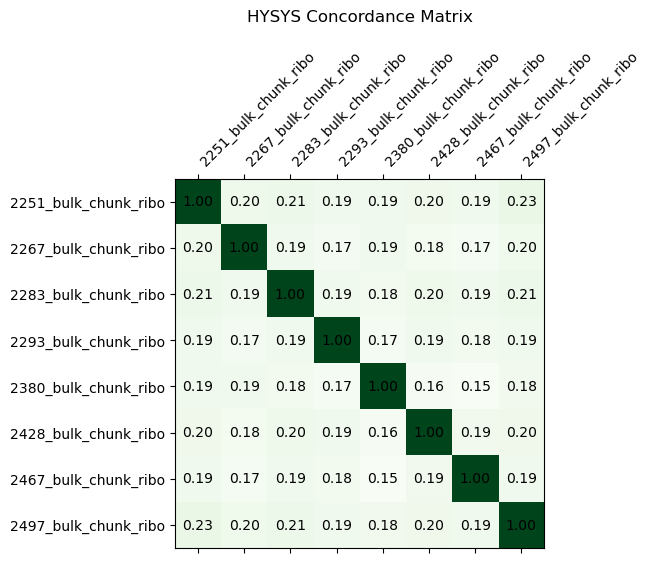

In [207]:
fig, ax = plt.subplots()
ax.matshow(hysys_matrix, cmap="Greens")

for (i, j), z in np.ndenumerate(hysys_matrix):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(hysys_matrix.columns)))
ax.set_yticks(np.arange(len(hysys_matrix.index)))
ax.set_xticklabels(hysys_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(hysys_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("HYSYS Concordance Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_hysys_concordance_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_hysys_concordance_matrix.pdf", bbox_inches="tight", dpi=300)

# CrossCheckFingerprints

In [208]:
fingerprints_df = pd.read_csv(DATA_PATH + f"fingerprints/{dataset}/crosscheck_metrics.txt", sep="\t", header=5)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [209]:
fingerprints_dict = {
    x: 
    x.replace("_bulk_chunk_ribo.bam", "")
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [210]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,2251_bulk_chunk_ribo,2251_bulk_chunk_ribo,851.099061,EXPECTED_MATCH
1,2251_bulk_chunk_ribo,2467_bulk_chunk_ribo,-212.226323,EXPECTED_MISMATCH
2,2251_bulk_chunk_ribo,2283_bulk_chunk_ribo,-221.992840,EXPECTED_MISMATCH
3,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,-231.943011,EXPECTED_MISMATCH
4,2251_bulk_chunk_ribo,2293_bulk_chunk_ribo,-182.431811,EXPECTED_MISMATCH


In [211]:
def long_df_to_matrix_fingerprints(df):
    matrix = pd.DataFrame()

    for x in df["LEFT_SAMPLE"].unique():
        for y in df["RIGHT_SAMPLE"].unique():
            corr_value = df.loc[(df["LEFT_SAMPLE"] == x) & (df["RIGHT_SAMPLE"] == y), "LOD_SCORE"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [212]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [213]:
fingerprints_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,851.099061,-231.943011,-221.992840,-182.431811,-153.799846,-184.218655,-212.226323,-251.537912
2267_bulk_chunk_ribo,-231.943011,722.187054,-201.161079,-170.474900,-181.048786,-160.745242,-209.946309,-190.730859
2283_bulk_chunk_ribo,-221.992840,-201.161079,856.252704,-178.916314,-180.205132,-196.369045,-199.528955,-190.885922
2293_bulk_chunk_ribo,-182.431811,-170.474900,-178.916314,669.926196,-116.489713,-173.365490,-175.432978,-144.848390
2380_bulk_chunk_ribo,-153.799846,-181.048786,-180.205132,-116.489713,630.655349,-158.636447,-143.325223,-126.826573
2428_bulk_chunk_ribo,-184.218655,-160.745242,-196.369045,-173.365490,-158.636447,793.301692,-193.176240,-185.456588
2467_bulk_chunk_ribo,-212.226323,-209.946309,-199.528955,-175.432978,-143.325223,-193.176240,845.807987,-212.703754
2497_bulk_chunk_ribo,-251.537912,-190.730859,-190.885922,-144.848390,-126.826573,-185.456588,-212.703754,860.099778


Text(0.5, 1.0, 'CrossCheckFingerprints LOD Score Matrix')

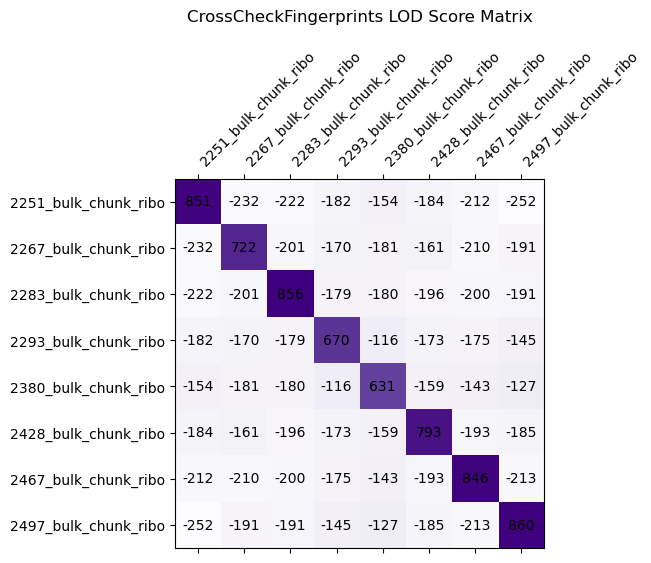

In [214]:
fig, ax = plt.subplots()
ax.matshow(fingerprints_matrix, cmap="Purples")

for (i, j), z in np.ndenumerate(fingerprints_matrix):
    ax.text(j, i, "{:.0f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(fingerprints_matrix.columns)))
ax.set_yticks(np.arange(len(fingerprints_matrix.index)))
ax.set_xticklabels(fingerprints_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(fingerprints_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("CrossCheckFingerprints LOD Score Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_fingerprints_lod_score_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_fingerprints_lod_score_matrix.pdf", bbox_inches="tight", dpi=300)

# BAMixChecker

In [215]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [216]:
bamixchecker_dict = {
    x: 
    x.replace("_bulk_chunk_ribo_filtered_rg.bam", "") 
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [217]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
2380_bulk_chunk_ribo,2467_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2267_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2293_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2497_bulk_chunk_ribo,0.0,Unmatched


In [218]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [219]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [220]:
bamixchecker_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2267_bulk_chunk_ribo,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2283_bulk_chunk_ribo,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
2293_bulk_chunk_ribo,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
2380_bulk_chunk_ribo,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
2428_bulk_chunk_ribo,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2467_bulk_chunk_ribo,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
2497_bulk_chunk_ribo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


Text(0.5, 1.0, 'BAMixChecker Concordance Matrix')

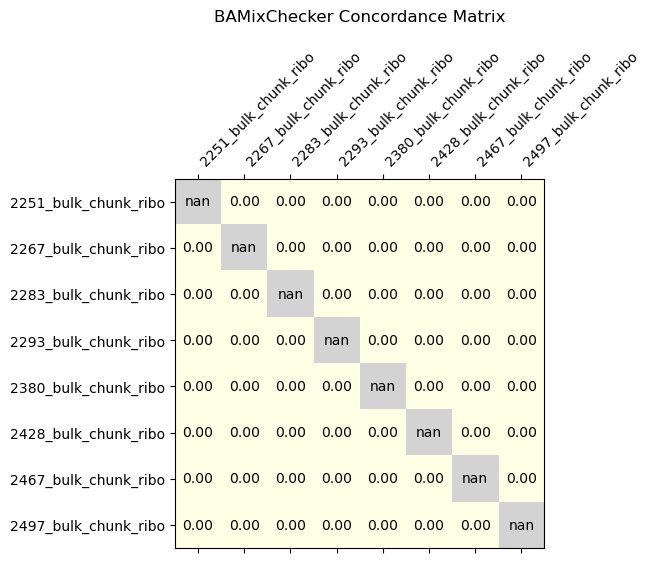

In [224]:
fig, ax = plt.subplots()
cmap = plt.cm.YlOrBr
cmap.set_bad(color="lightgray")

ax.matshow(bamixchecker_matrix, cmap=cmap, vmin=0, vmax=1)

for (i, j), z in np.ndenumerate(bamixchecker_matrix):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(bamixchecker_matrix.columns)))
ax.set_yticks(np.arange(len(bamixchecker_matrix.index)))
ax.set_xticklabels(bamixchecker_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(bamixchecker_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("BAMixChecker Concordance Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_bamixchecker_concordance_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_bamixchecker_concordance_matrix.pdf", bbox_inches="tight", dpi=300)

# Tool comparison

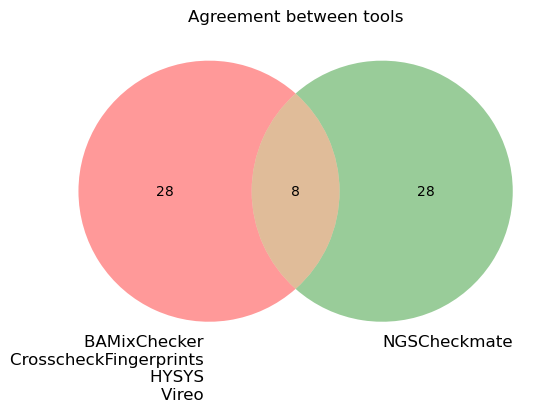

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300